# 🎙️ NPPE-2: Multilingual Speech Recognition Pipeline
**Strategy:**  load audio → detect language → route → transcribe → normalize

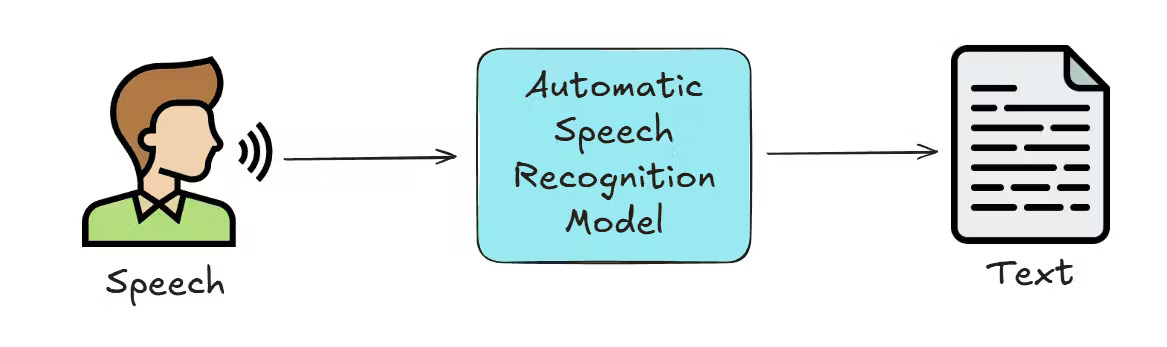

# 0. Installing libraries

* `transformers` and `accelerate` are needed for loading and running Whisper Large-v3 and the AI4Bharat IndicConformer model from HuggingFace.
* `openai-whisper` is installed separately because it provides the lightweight Whisper-base model used only for **language identification (LID)** — not transcription.
* `soundfile`, `librosa`, and `torchaudio` are for audio I/O and resampling (loading `.wav` files, converting to 16kHz mono).
* `jiwer` is used to compute the Word Error Rate (WER) — the evaluation metric for this competition.
* `tqdm` is for progress bars during inference over ~2000 samples.

In [1]:
%%capture
!pip install -q transformers>=4.40.0 accelerate
!pip install -q openai-whisper
!pip install -q soundfile librosa jiwer tqdm
!pip install -q torchaudio
print("All packages installed")


# 1. HuggingFace Authentication

* The AI4Bharat IndicConformer-600M model and Whisper Large-v3 are gated / large models hosted on HuggingFace Hub.
* Kaggle Secrets is used to store the HF token securely instead of hardcoding it.
* `login(token=hf_token)` logs in programmatically without triggering an interactive prompt — this is important for notebook-based submissions where interactive input is not possible.

In [2]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

secrets  = UserSecretsClient()
hf_token = secrets.get_secret("HF_TOKEN")
login(token=hf_token, add_to_git_credential=False)
print("Logged in to HuggingFace")


Logged in to HuggingFace


## 2. Imports & Config

In [3]:
import os, re, warnings, gc, tempfile
import numpy as np
import pandas as pd
import torch
import torchaudio
import librosa
import soundfile as sf
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── Confirmed paths from EDA ───────────────────────────────────────────────────
COMP_DIR        = Path("/kaggle/input/competitions/multilingual-speech-recognition")
TRAIN_CSV       = COMP_DIR / "train.csv"
TEST_CSV        = COMP_DIR / "test.csv"
TRAIN_AUDIO_DIR = COMP_DIR / "competition_data" / "train"
TEST_AUDIO_DIR  = COMP_DIR / "competition_data" / "test"
OUTPUT_DIR      = Path("/kaggle/working")
SUBMISSION_PATH = OUTPUT_DIR / "submission.csv"

TARGET_SR = 16000
AUDIO_COL = "audio"
TEXT_COL  = "text"

# ── Dual GPU setup ─────────────────────────────────────────────────────────────
DEVICE_0 = "cuda:0" if torch.cuda.is_available() else "cpu"
DEVICE_1 = "cuda:1" if torch.cuda.device_count() > 1 else DEVICE_0

print(f"  GPUs available : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"   cuda:{i} → {props.name} | {props.total_memory/1e9:.1f} GB")
print(f"\n   IndicConformer → {DEVICE_0}")
print(f"   Whisper        → {DEVICE_1}")
print(f"   Train audio    : {TRAIN_AUDIO_DIR.exists()}")
print(f"   Test  audio    : {TEST_AUDIO_DIR.exists()}")


  GPUs available : 2
   cuda:0 → Tesla T4 | 15.6 GB
   cuda:1 → Tesla T4 | 15.6 GB

   IndicConformer → cuda:0
   Whisper        → cuda:1
   Train audio    : True
   Test  audio    : True


# 3. Downloading dataset

* Reading the train and test CSVs into pandas DataFrames.
* The `audio` column contains just the filename (e.g. `0001.wav`), not the full path — we will combine it with `TRAIN_AUDIO_DIR` / `TEST_AUDIO_DIR` when loading audio.
* `display(train_df.head(3))` is used to quickly sanity-check the column structure (`audio`, `text` for train; `audio` only for test).

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f"Train : {len(train_df):,} rows | columns: {list(train_df.columns)}")
print(f"Test  : {len(test_df):,}  rows | columns: {list(test_df.columns)}")
display(train_df.head(3))
display(test_df.head(3))


Train : 2,000 rows | columns: ['id', 'audio', 'text']
Test  : 100  rows | columns: ['id', 'audio']


,id,audio,text
0,0,audio_00000.wav,you had quoted plutarch line.
1,1,audio_00001.wav,மலையேறுதலில் வந்து பார்த்தீங்கன்னா ஜஸ்ட்டு நம்...
2,2,audio_00002.wav,to do his phd in engineering about four years ...


,id,audio
0,0,audio_00000.wav
1,1,audio_00001.wav
2,2,audio_00002.wav


# 4. Audio Loaders

* Two audio loader functions were needed because Whisper and IndicConformer expect different input formats.
* `load_audio_numpy` uses `librosa` → returns a float32 numpy array. Used by Whisper (both LID and Large-v3) which internally converts numpy to mel-spectrogram.
* `load_audio_tensor` uses `torchaudio` → returns a `(1, T)` float32 tensor. Used by IndicConformer which operates directly on waveform tensors.
* Both loaders do the same preprocessing: **convert to mono + resample to 16kHz**. Resampling is essential because the raw clips may be at 44.1kHz or other rates, but the models were pretrained at 16kHz.
* A sanity check at the bottom prints the shape of both outputs on the first training file to confirm the loaders work.

In [5]:
def load_audio_numpy(filename: str, audio_dir: Path) -> np.ndarray:
    """Load wav → 16kHz mono → float32 numpy. Used by Whisper & LID."""
    y, sr = librosa.load(str(audio_dir / filename), sr=None, mono=True)
    if sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
    return y.astype(np.float32)


def load_audio_tensor(filename: str, audio_dir: Path) -> torch.Tensor:
    """Load wav → 16kHz mono → (1,T) float32 tensor. Used by IndicConformer."""
    wav, sr = torchaudio.load(str(audio_dir / filename))
    wav = torch.mean(wav, dim=0, keepdim=True)
    if sr != TARGET_SR:
        wav = torchaudio.functional.resample(wav, orig_freq=sr, new_freq=TARGET_SR)
    return wav.float()


# Sanity check
f0 = train_df[AUDIO_COL].iloc[0]
print(f"   Audio loaders work on: {f0}")
print(f"   numpy  : {load_audio_numpy(f0, TRAIN_AUDIO_DIR).shape}")
print(f"   tensor : {load_audio_tensor(f0, TRAIN_AUDIO_DIR).shape}")


   Audio loaders work on: audio_00000.wav
   numpy  : (46400,)
   tensor : torch.Size([1, 46400])


# 5. Language Detection

* Instead of transcribing blindly and detecting language from the output text, I wanted to detect the language **first** from the audio, then route to the correct model.
* I chose `whisper-base` for language identification (LID) rather than a bigger model because:
  - LID is a much simpler task than transcription — the smallest Whisper model is sufficient.
  - `whisper-base` is fast and fits easily on GPU 0 alongside IndicConformer.
  - Running LID on `whisper-large-v3` would waste compute since we only need the ISO 639-1 code.
* `pad_or_trim` ensures every clip is exactly 30 seconds (Whisper's expected input length) — shorter clips are padded and longer clips are trimmed.
* `log_mel_spectrogram` converts the waveform into the log-Mel spectrogram format Whisper expects.
* `detect_language` returns a dict of `{lang_code: probability}`, and we pick the language with highest probability.
* A spot-check on 5 training samples confirms LID is working before using it on all 2000 samples.

In [6]:
import whisper as whisper_lib

print("   Loading Whisper base for language detection...")
lid_model = whisper_lib.load_model("base", device=DEVICE_0)
print("   Whisper base loaded for LID")

def detect_language(audio_np: np.ndarray) -> str:
    """
    Detect language from audio using Whisper base.
    Returns raw ISO 639-1 code — routing is handled separately.
    """
    audio_padded = whisper_lib.pad_or_trim(audio_np)
    mel = whisper_lib.log_mel_spectrogram(audio_padded).to(DEVICE_0)
    _, probs = lid_model.detect_language(mel)
    return max(probs, key=probs.get)

# Spot check
print("\n── LID spot check (5 samples) ──")
for i in range(min(5, len(train_df))):
    row   = train_df.iloc[i]
    audio = load_audio_numpy(row[AUDIO_COL], TRAIN_AUDIO_DIR)
    lang  = detect_language(audio)
    print(f"  [{i}] {row[AUDIO_COL]} → raw_lang: {lang:4s} | ref: {str(row[TEXT_COL])[:55]}")


   Loading Whisper base for language detection...


100%|███████████████████████████████████████| 139M/139M [00:02<00:00, 53.7MiB/s]


   Whisper base loaded for LID

── LID spot check (5 samples) ──
  [0] audio_00000.wav → raw_lang: en   | ref: you had quoted plutarch line.
  [1] audio_00001.wav → raw_lang: ta   | ref: மலையேறுதலில் வந்து பார்த்தீங்கன்னா ஜஸ்ட்டு நம்ம மலை ஏறி
  [2] audio_00002.wav → raw_lang: en   | ref: to do his phd in engineering about four years ago.
  [3] audio_00003.wav → raw_lang: en   | ref: maybe he was not at home.
  [4] audio_00004.wav → raw_lang: en   | ref: BUT WE DIDN'T BREAK HIS OLD WINDOW YOU KNOW EXPOSTULATE


# 6. Some analysis

### Conclusions

* `langdetect` is used on the **training-set transcripts** (not the audio) just to get a ground-truth count of each language.
* There are primarily three languages in the train dataset — English, Hindi, Tamil.
* Plotting a bar chart and pie chart side-by-side to see both raw counts and percentage share.
* This gives us a reference for what the LID output on audio *should* look like in terms of distribution.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


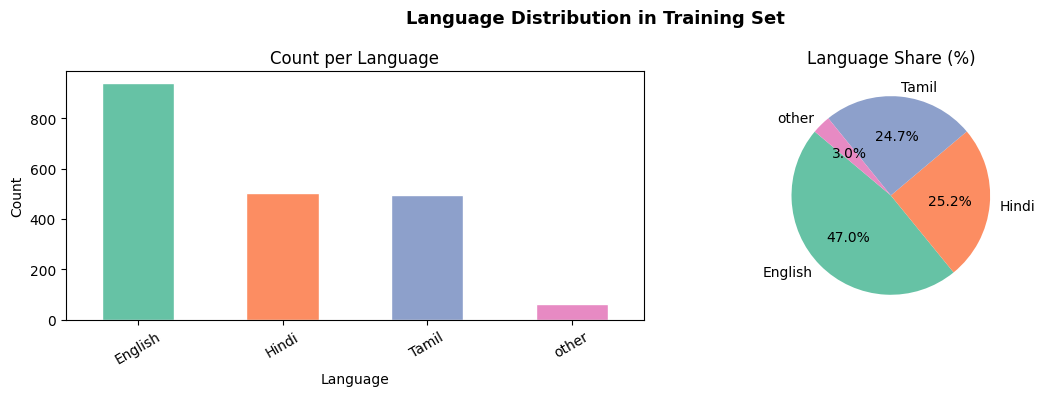

detected_lang
English    940
Hindi      505
Tamil      494
other       61
Name: count, dtype: int64


In [7]:
!pip install langdetect -q

from langdetect import detect, DetectorFactory
import matplotlib.pyplot as plt
import seaborn as sns

DetectorFactory.seed = 42
LANG_MAP = {"hi": "Hindi", "ta": "Tamil", "en": "English"}

train_df["detected_lang"] = train_df["text"].apply(
    lambda x: LANG_MAP.get(detect(str(x)), "other")
)
lang_counts = train_df["detected_lang"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Language Distribution in Training Set", fontsize=13, fontweight="bold")

lang_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("Set2"), edgecolor="white")
axes[0].set_title("Count per Language")
axes[0].set_xlabel("Language"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

axes[1].pie(lang_counts, labels=lang_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"), startangle=140)
axes[1].set_title("Language Share (%)")

plt.tight_layout()
plt.show()
print(lang_counts)

In [8]:
pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 62.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# 7. Loading AI4Bharat's IndicConformer-600M-multilingual

* The choice of models was arrived at after initial trials and error analysis on the training set.
* **Wav2Vec2** was ruled out — its pretraining objective is self-supervised and it would need heavy fine-tuning on labeled data, which is not practical with limited compute and ~2000 training samples.
* **Whisper-medium** alone gave mediocre Hindi and Tamil transcription because Whisper's Indic-language coverage is weaker than its English coverage.
* **AI4Bharat's IndicConformer-600M-multilingual** was chosen for Hindi and Tamil because it was pretrained on 22 Indian languages and produces much cleaner Indic-script transcriptions. This became the **Indic model** in the hybrid pipeline.
* `trust_remote_code=True` is required because IndicConformer uses a custom model class that isn't part of the standard transformers library.
* It's moved to `DEVICE_0` (GPU 0) to keep GPU 1 free for Whisper Large-v3.
* `.eval()` disables dropout since we're only doing inference.

In [9]:
from transformers import AutoModel

print("⏳ Loading ai4bharat/indic-conformer-600m-multilingual...")
indic_model = AutoModel.from_pretrained(
    "ai4bharat/indic-conformer-600m-multilingual",
    trust_remote_code=True,
)
indic_model = indic_model.to(DEVICE_0)
indic_model.eval()
print(f"  IndicConformer-600M loaded on {DEVICE_0}")
print(f"   VRAM used: {torch.cuda.memory_allocated(0)/1e9:.2f} GB / "
      f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


⏳ Loading ai4bharat/indic-conformer-600m-multilingual...


config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

model_onnx.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indic-conformer-600m-multilingual:
- model_onnx.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Please check FRAME_DURATION_MS. The timestamps can be inaccurate
Please check FRAME_DURATION_MS. The timestamps can be inaccurate


Fetching 404 files:   0%|          | 0/404 [00:00<?, ?it/s]

Please check FRAME_DURATION_MS. The timestamps can be inaccurate
  IndicConformer-600M loaded on cuda:0
   VRAM used: 0.30 GB / 15.6 GB


# 8. Loading Whisper Large-v3 (English transcription)

* `whisper-large-v3` is used specifically for **English** transcription (and as a fallback for anything the routing table can't classify).
* `torch_dtype=torch.float16` loads the model in half precision — this roughly halves the VRAM footprint (from ~6GB to ~3GB) with negligible accuracy loss, and also speeds up inference on modern GPUs.
* The model is placed on `DEVICE_1` (GPU 1) so it runs independently of IndicConformer on GPU 0. This means both models stay loaded and we don't have to unload/reload between samples.
* `WhisperProcessor` handles both the feature extraction (waveform → log-Mel spectrogram) and the tokenizer (token IDs → text).

In [10]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration

WHISPER_ID = "openai/whisper-large-v3"
print(f"  Loading {WHISPER_ID}...")

whisper_processor = WhisperProcessor.from_pretrained(WHISPER_ID)
whisper_model = WhisperForConditionalGeneration.from_pretrained(
    WHISPER_ID,
    torch_dtype=torch.float16,
)
whisper_model = whisper_model.to(DEVICE_1)
whisper_model.eval()
print(f"   Whisper large-v3 loaded on {DEVICE_1}")
print(f"   VRAM used: {torch.cuda.memory_allocated(1)/1e9:.2f} GB / "
      f"{torch.cuda.get_device_properties(1).total_memory/1e9:.1f} GB")


  Loading openai/whisper-large-v3...


preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

   Whisper large-v3 loaded on cuda:1
   VRAM used: 3.09 GB / 15.6 GB


# 9. Script-Aware Language Routing Table

* After running Whisper-base LID on the full training set, I observed that **Whisper misdetects Indic audio as other languages very frequently** — this is the core insight that drove the routing strategy.
* Key misdetection patterns from error analysis:
  - Tamil audio → often detected as `ml` (Malayalam, 41 samples!), `kn`, `te`, `ja`, `tl`
  - Hindi audio → often detected as `ur` (Urdu, 65 samples — biggest issue), plus many European codes (`ro`, `pt`, `cs`, `tr`, etc.) where Whisper was confused by Hindi phonemes
* Rather than trusting Whisper's raw LID, I built a **routing table** that collapses ~30 possible LID outputs into just three routes:
  - Anything in `TAMIL_MISDETECTIONS` → IndicConformer with `lang_code="ta"` (RNNT decoding)
  - Anything in `HINDI_MISDETECTIONS` → IndicConformer with `lang_code="hi"` (RNNT decoding)
  - Everything else → Whisper Large-v3 in English mode
* **RNNT decoding** was preferred over **CTC** for IndicConformer because RNNT gave noticeably better WER on Indic transcriptions during validation (slightly slower but worth it).
* `transcribe_english` uses **beam search** (`num_beams=5`) for better English accuracy — greedy decoding tended to produce more WER on longer clips.
* `normalize` lowercases the text and collapses whitespace. The instructor confirmed lowercase is accepted for English, so no need for case-sensitive handling.
* A routing spot-check at the bottom confirms the table is wired correctly for a mix of input codes.

In [11]:
# ── Routing table built from full training set error analysis 

# Languages that Whisper misdetects for TAMIL audio
TAMIL_MISDETECTIONS = {
    "ta",   # correct Tamil detection
    "ml",   # Malayalam — most common Tamil misdetection (41 samples!)
    "kn",   # Kannada
    "te",   # Telugu
    "ja",   # Japanese — Tamil phonemes confused
    "tl",   # Filipino/Tagalog
}

# Languages that Whisper misdetects for HINDI audio
HINDI_MISDETECTIONS = {
    "hi",   # correct Hindi detection
    "ur",   # Urdu — 65 samples, highest impact fix
    "ne",   # Nepali
    "mr",   # Marathi
    "pa",   # Punjabi
    "bn",   # Bengali
    "si",   # Sinhala
    "id",   # Indonesian
    "ms",   # Malay
    "ro",   # Romanian — 11 samples Hindi misdetected
    "pt",   # Portuguese — 7 samples Hindi misdetected
    "cs",   # Czech — Hindi misdetected
    "tr",   # Turkish — Hindi misdetected
    "ar",   # Arabic — Hindi misdetected
    "fa",   # Persian/Farsi
    "el",   # Greek
    "ru",   # Russian
    "vi",   # Vietnamese
    "am",   # Amharic
    "hr",   # Croatian
    "lv",   # Latvian
    "sl",   # Slovenian
    "is",   # Icelandic
    "fi",   # Finnish
    "da",   # Danish
    "it",   # Italian
    "es",   # Spanish
    "pl",   # Polish
    "th",   # Thai
    "ko",   # Korean
}

def get_route(detected_lang: str) -> tuple:
    """
    Returns (model_type, lang_code) based on detected language.
    model_type: 'indic_tamil' | 'indic_hindi' | 'whisper'
    """
    if detected_lang in TAMIL_MISDETECTIONS:
        return ("indic_tamil", "ta")
    elif detected_lang in HINDI_MISDETECTIONS:
        return ("indic_hindi", "hi")
    else:
        return ("whisper", "en")   # true English or unknown → Whisper


# ── Transcription functions 
def transcribe_indic(wav_tensor: torch.Tensor, lang_code: str) -> str:
    """
    Transcribe using IndicConformer-600M with RNNT decoding.
    RNNT is more accurate than CTC (slightly slower but worth it).
    """
    wav = wav_tensor.to(DEVICE_0)
    with torch.no_grad():
        text = indic_model(wav, lang_code, "rnnt")
    return str(text).strip()


def transcribe_english(audio_np: np.ndarray) -> str:
    """Transcribe using Whisper large-v3 with beam search."""
    inputs = whisper_processor(
        audio_np,
        sampling_rate=TARGET_SR,
        return_tensors="pt"
    ).input_features.to(DEVICE_1).half()

    with torch.no_grad():
        pred_ids = whisper_model.generate(
            inputs,
            language="en",
            task="transcribe",
            num_beams=5,
        )
    return whisper_processor.batch_decode(
        pred_ids, skip_special_tokens=True
    )[0].strip()


def transcribe(filename: str, audio_dir: Path, detected_lang: str) -> str:
    """
    Master router — uses routing table to pick correct model.
    """
    model_type, lang_code = get_route(detected_lang)

    if model_type in ("indic_tamil", "indic_hindi"):
        wav = load_audio_tensor(filename, audio_dir)
        return transcribe_indic(wav, lang_code)
    else:
        audio = load_audio_numpy(filename, audio_dir)
        return transcribe_english(audio)


def normalize(text: str) -> str:
    """
    Normalize text for WER computation and final submission.
    Lowercase + collapse whitespace.
    Instructor confirmed lowercase is accepted for English.
    """
    text = str(text).lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text


print("    Routing table + transcription functions ready")
print(f"   Tamil  route : {len(TAMIL_MISDETECTIONS)} language codes → IndicConformer (ta) RNNT")
print(f"   Hindi  route : {len(HINDI_MISDETECTIONS)} language codes → IndicConformer (hi) RNNT")
print(f"   English route: everything else → Whisper large-v3")

# Quick routing test
for test_lang in ["en", "hi", "ta", "ur", "ml", "ro", "pt", "ja"]:
    route = get_route(test_lang)
    print(f"   {test_lang:4s} → {route}")


    Routing table + transcription functions ready
   Tamil  route : 6 language codes → IndicConformer (ta) RNNT
   Hindi  route : 30 language codes → IndicConformer (hi) RNNT
   English route: everything else → Whisper large-v3
   en   → ('whisper', 'en')
   hi   → ('indic_hindi', 'hi')
   ta   → ('indic_tamil', 'ta')
   ur   → ('indic_hindi', 'hi')
   ml   → ('indic_tamil', 'ta')
   ro   → ('indic_hindi', 'hi')
   pt   → ('indic_hindi', 'hi')
   ja   → ('indic_tamil', 'ta')


# 10. Validation on training set

* Before running on test data, validating on 100 training samples to confirm the routing pipeline works end-to-end.
* Per-sample WER is computed so we can see *which* samples are failing, not just the aggregate score.
* WER is also broken down by **route** (`indic_tamil`, `indic_hindi`, `whisper`) and by **raw detected language** — this helps identify whether a particular route is underperforming and whether the routing table needs adjustment.
* The "wrong predictions" table (sorted by WER descending) surfaces the worst cases so I can inspect them manually and iterate on routing / normalization.

In [12]:
from jiwer import wer as compute_wer

VALIDATE_N = 100   
print(f"  Validating on {VALIDATE_N} training samples...\n")

val_results = []
for _, row in tqdm(train_df.head(VALIDATE_N).iterrows(), total=VALIDATE_N):
    fname = row[AUDIO_COL]
    ref   = str(row[TEXT_COL])
    try:
        audio_np     = load_audio_numpy(fname, TRAIN_AUDIO_DIR)
        detected     = detect_language(audio_np)
        model_type, lang_code = get_route(detected)
        pred         = transcribe(fname, TRAIN_AUDIO_DIR, detected)
    except Exception as e:
        print(f"     {fname}: {e}")
        detected, model_type, lang_code, pred = "err", "err", "err", ""

    val_results.append({
        "file"       : fname,
        "raw_lang"   : detected,
        "routed_to"  : f"{model_type}({lang_code})",
        "reference"  : ref,
        "prediction" : pred,
        "ref_norm"   : normalize(ref),
        "pred_norm"  : normalize(pred),
    })

val_df = pd.DataFrame(val_results)

# ── Per-sample WER 
val_df["sample_wer"] = val_df.apply(
    lambda r: compute_wer(r["ref_norm"], r["pred_norm"]), axis=1
)

# ── Overall WER (normalized both sides) 
overall_wer = compute_wer(
    val_df["ref_norm"].tolist(),
    val_df["pred_norm"].tolist()
)


print(f"  Overall WER ({VALIDATE_N} samples): {overall_wer:.4f}")
print(f"{'='*55}")
print(f"  WER by routed model:")
for route, grp in val_df.groupby("routed_to"):
    if len(grp) == 0: continue
    rwer = compute_wer(grp["ref_norm"].tolist(), grp["pred_norm"].tolist())
    print(f"    {route:30s} → WER: {rwer:.4f}  ({len(grp)} samples)")
print(f"{'='*55}")
print(f"  WER by raw detected language:")
for lang, grp in val_df.groupby("raw_lang"):
    if len(grp) < 3: continue
    lwer = compute_wer(grp["ref_norm"].tolist(), grp["pred_norm"].tolist())
    print(f"    {lang:6s} → WER: {lwer:.4f}  ({len(grp)} samples)")
print(f"{'='*55}")

# ── Wrong predictions 
wrong_df = val_df[val_df["sample_wer"] > 0].sort_values("sample_wer", ascending=False)
print(f"\n  Perfect (WER=0) : {(val_df['sample_wer']==0).sum()}")
print(f"  Wrong  (WER>0)  : {len(wrong_df)}")
display(val_df[["file","raw_lang","routed_to","ref_norm","pred_norm","sample_wer"]].head(15))


  Validating on 100 training samples...




  0%|          | 0/100 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.g

  Overall WER (100 samples): 0.1362
  WER by routed model:
    indic_hindi(hi)                → WER: 0.1468  (23 samples)
    indic_tamil(ta)                → WER: 0.3597  (26 samples)
    whisper(en)                    → WER: 0.0400  (51 samples)
  WER by raw detected language:
    en     → WER: 0.0352  (50 samples)
    hi     → WER: 0.1208  (17 samples)
    ta     → WER: 0.3498  (24 samples)
    ur     → WER: 0.1042  (4 samples)

  Perfect (WER=0) : 37
  Wrong  (WER>0)  : 63


,file,raw_lang,routed_to,ref_norm,pred_norm,sample_wer
0,audio_00000.wav,en,whisper(en),you had quoted plutarch line.,you had coated pluttered line.,0.400000
1,audio_00001.wav,ta,indic_tamil(ta),மலையேறுதலில் வந்து பார்த்தீங்கன்னா ஜஸ்ட்டு நம்...,மலை ஏறுதில் வந்து பார்த்திங்கன்னா ஜஸ்ட்டு நம்ம...,0.305556
2,audio_00002.wav,en,whisper(en),to do his phd in engineering about four years ...,to do his phd in engineering about four years ...,0.000000
3,audio_00003.wav,en,whisper(en),maybe he was not at home.,maybe he was not at home.,0.000000
4,audio_00004.wav,en,whisper(en),but we didn't break his old window you know ex...,but we didn't break his old window you know ex...,0.000000
5,audio_00005.wav,ro,indic_hindi(hi),इस किताब में दर्ज कुल तेरह चैप्टरों में शामिल ...,इस किताब में दर्ज कुल तेरह चैप्टरों में शामिल ...,0.000000
6,audio_00006.wav,ta,indic_tamil(ta),அவன் உங்களை நியாபகம் இருக்குன்னு வந்து பேசுவான...,அவன் உங்களை ஞாபகம் இருக்குதுன்னு வந்து பேசுவான...,0.222222
7,audio_00007.wav,en,whisper(en),you had mentioned over the phone.,you had mentioned over the phone.,0.000000
8,audio_00008.wav,ur,indic_hindi(hi),में चारों तरफ से घिर कर रह गई फौज की एक टुकड़ी,में चारों तरफ़ से घिर कर रह गई फ़ौज की एक टुकड़ी,0.166667
9,audio_00009.wav,ta,indic_tamil(ta),அது இல்லைனா சும்மா கட்டி மறு எண்ணைய் ஊற்றி சரி...,அது இல்லைன்னா சும்மா கட்டி மரு எண்ணெய் ஊற்றி ச...,0.423077


# 11. Full Test Set Inference

* Running the complete pipeline on all test samples — load audio → detect language → route → transcribe → normalize.
* `route_counts` tracks how many test samples went to each route. This is a useful sanity check: if the routing distribution on test looks wildly different from train, something is off.
* Any exception during inference is caught and logged — a single broken audio file should not kill the whole run, so the sample is just marked as empty and moves on (handled by the fallback in the next cell).
* The `_lang` and `_route` columns are kept in the intermediate DataFrame (prefixed with `_`) for debugging; they are dropped before saving the submission.

In [13]:
print(f"  Running inference on {len(test_df)} test samples...\n")

test_results = []
route_counts = {}

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    fname = row[AUDIO_COL]
    try:
        audio_np = load_audio_numpy(fname, TEST_AUDIO_DIR)
        detected = detect_language(audio_np)
        pred     = transcribe(fname, TEST_AUDIO_DIR, detected)
        pred     = normalize(pred)
        model_type, lang_code = get_route(detected)
        route    = f"{model_type}({lang_code})"
    except Exception as e:
        print(f"    {fname}: {e}")
        detected, route, pred = "err", "err", ""

    route_counts[route] = route_counts.get(route, 0) + 1
    test_results.append({
        "audio"  : fname,
        "text"   : pred,
        "_lang"  : detected,
        "_route" : route,
    })

pred_df = pd.DataFrame(test_results)

print(f"\n Inference complete")
print(f"   Routing distribution:")
for route, cnt in sorted(route_counts.items(), key=lambda x: -x[1]):
    print(f"     {route:35s} : {cnt} samples")
print(f"   Empty predictions: {(pred_df['text'].str.strip() == '').sum()}")
display(pred_df[["audio","_lang","_route","text"]].head(10))


  Running inference on 100 test samples...




100%|██████████| 100/100 [02:41<00:00,  1.61s/it]


 Inference complete
   Routing distribution:
     whisper(en)                         : 49 samples
     indic_tamil(ta)                     : 30 samples
     indic_hindi(hi)                     : 21 samples
   Empty predictions: 1


,audio,_lang,_route,text
0,audio_00000.wav,hi,indic_hindi(hi),इनमें जेपी मॉर्गन सिमस और ब्लैक रॉक के सीईओ शा...
1,audio_00001.wav,bn,indic_hindi(hi),एक हज़ार नौ सौ नब्बे में जहां दो मुस्लिम उम्मी...
2,audio_00002.wav,ta,indic_tamil(ta),மாட்டை வந்து மாட்டுப்பொங்கல் முடிஞ்சு மாட்டுப்...
3,audio_00003.wav,ta,indic_tamil(ta),அறிவிக்கிற மாதிரி ஒரு படை இருக்கணும்
4,audio_00004.wav,en,whisper(en),and by this i knew the violence of my love i l...
5,audio_00005.wav,en,whisper(en),really the beginning as the event was the show...
6,audio_00006.wav,en,whisper(en),i'm sure that is all you could expect from us ...
7,audio_00007.wav,hi,indic_hindi(hi),जहां तक संभव हो सीधी उड़ान लें
8,audio_00008.wav,ta,indic_tamil(ta),செயற்கையான வெளிச்சத்தை நோக்கி தான் போகிறாங்க ஒ...
9,audio_00009.wav,hi,indic_hindi(hi),हज़ार नौ सौ पैंसठ करोड़ रुपए का खर्च आया था


# 12. Build & Save Submission

* Reading `sample_submission.csv` only to verify that our submission has the exact same columns (`audio`, `text`) as expected by the evaluator.
* **Empty-prediction fallback**: if any prediction came out empty (e.g. IndicConformer failed on a particular clip), we retry that sample with Whisper Large-v3 as a last resort. If even that fails, we insert a placeholder word (`"the"`) so the row is not blank — a blank row would be a deletion across the whole reference, hurting WER much more than a single wrong word.
* `assert` statements confirm (a) the row count matches the test set and (b) the columns match the sample submission exactly — catching any accidental shape mismatch before upload.
* Saving to `/kaggle/working/submission.csv`, which is the path Kaggle expects for scoring.

In [14]:
sample_df     = pd.read_csv(COMP_DIR / "sample_submission.csv")
submission_df = pred_df[["audio", "text"]].copy()

# Handle empty predictions with Whisper fallback
empty_mask = submission_df["text"].str.strip() == ""
if empty_mask.sum() > 0:
    print(f"  {empty_mask.sum()} empty — retrying with Whisper...")
    for idx in submission_df[empty_mask].index:
        fname = submission_df.loc[idx, "audio"]
        try:
            audio_np = load_audio_numpy(fname, TEST_AUDIO_DIR)
            pred     = normalize(transcribe_english(audio_np))
            submission_df.loc[idx, "text"] = pred
            print(f"   {fname} → {pred[:60]}")
        except Exception as e:
            print(f"   {fname}: {e}")
            submission_df.loc[idx, "text"] = "the"

assert len(submission_df) == len(test_df), "Row count mismatch"
assert list(submission_df.columns) == list(sample_df.columns), "Column mismatch"

still_empty = submission_df["text"].str.strip().eq("").sum()

submission_df.to_csv(SUBMISSION_PATH, index=False)
print(f" Submission saved → {SUBMISSION_PATH}")
print(f"   Shape: {submission_df.shape}")
display(submission_df.head(10))

  1 empty — retrying with Whisper...
   audio_00088.wav → 1640, there is no discount, sir. please do it carefully, sir
 Submission saved → /kaggle/working/submission.csv
   Shape: (100, 2)


,audio,text
0,audio_00000.wav,इनमें जेपी मॉर्गन सिमस और ब्लैक रॉक के सीईओ शा...
1,audio_00001.wav,एक हज़ार नौ सौ नब्बे में जहां दो मुस्लिम उम्मी...
2,audio_00002.wav,மாட்டை வந்து மாட்டுப்பொங்கல் முடிஞ்சு மாட்டுப்...
3,audio_00003.wav,அறிவிக்கிற மாதிரி ஒரு படை இருக்கணும்
4,audio_00004.wav,and by this i knew the violence of my love i l...
5,audio_00005.wav,really the beginning as the event was the show...
6,audio_00006.wav,i'm sure that is all you could expect from us ...
7,audio_00007.wav,जहां तक संभव हो सीधी उड़ान लें
8,audio_00008.wav,செயற்கையான வெளிச்சத்தை நோக்கி தான் போகிறாங்க ஒ...
9,audio_00009.wav,हज़ार नौ सौ पैंसठ करोड़ रुपए का खर्च आया था
